In [1]:
# Instalar timm (library con Swin Transformer)
!pip install timm -q

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import timm
import time
from sklearn.metrics import f1_score, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

In [7]:

ruta_base = '/kaggle/input/datasets/amelianadiamaziuk/ourdata/ourData'

if not os.path.exists(ruta_base):
    print(f"Error: El directorio '{ruta_base}' no existe.")
else:
    print(f"Dataset encontrado en: {ruta_base}")


Dataset encontrado en: /kaggle/input/datasets/amelianadiamaziuk/ourdata/ourData


In [8]:
# Transformaciones SOLO resize y normalize (sin augmentation)
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [15]:
class ImageFolder(datasets.ImageFolder):
    def __getitem__(self, index):
        try:
            return super(ImageFolder, self).__getitem__(index)
        except:
            return self.__getitem__(index + 1)

In [16]:
ruta_dataset = ruta_base + '/'

train_set = ImageFolder(root=ruta_dataset + 'train/', transform=transform_train)
val_set = ImageFolder(root=ruta_dataset + 'val/', transform=transform_val)
test_set = ImageFolder(root=ruta_dataset + 'test/', transform=transform_val)

print(f"Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}")
print(f"Clases: {train_set.classes}")


Train: 377 | Val: 78 | Test: 89
Clases: ['Cups', 'Forks', 'Glasses', 'Knives', 'Plates', 'Spoons']


In [17]:
batch_size = 16

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

print(f"Batches en train: {len(train_loader)}")
print(f"Batches en val: {len(val_loader)}")
print(f"Batches en test: {len(test_loader)}")

Batches en train: 24
Batches en val: 5
Batches en test: 6


In [19]:
# Cargar Swin Transformer Tiny pre-entrenado con ImageNet
modelo_swin = timm.create_model('swin_tiny_patch4_window7_224',
                                 pretrained=True,
                                 num_classes=6)

print("Swin Transformer Tiny cargado correctamente")
print(f"Total de parámetros: {sum(p.numel() for p in modelo_swin.parameters()):,}")

Swin Transformer Tiny cargado correctamente
Total de parámetros: 27,523,968


In [20]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando: {device}")

modelo_swin = modelo_swin.to(device)

# Optimizer y Loss (fine-tuning con LR muy bajo)
optimizer = optim.AdamW(modelo_swin.parameters(), lr=0.0001)
criterio = nn.CrossEntropyLoss()

epochs = 20

Usando: cuda


In [22]:
hist_loss_train = []
hist_acc_val = []

start_time = time.time()

print("="*70)
print("EXPERIMENTO 4: SWIN TRANSFORMER TINY - ENTRENAMIENTO")
print("="*70)

for epoch in range(epochs):
    # ENTRENAMIENTO
    modelo_swin.train()
    loss_total = 0

    for imagenes, etiquetas in train_loader:
        imagenes = imagenes.to(device)
        etiquetas = etiquetas.to(device)

        optimizer.zero_grad()
        salida = modelo_swin(imagenes)
        loss = criterio(salida, etiquetas)
        loss.backward()
        optimizer.step()

        loss_total += loss.item()

    loss_medio = loss_total / len(train_loader)

    # VALIDACIÓN
    modelo_swin.eval()
    correctas = 0
    total = 0

    with torch.no_grad():
        for imagenes, etiquetas in val_loader:
            imagenes = imagenes.to(device)
            etiquetas = etiquetas.to(device)
            salida = modelo_swin(imagenes)
            _, predicciones = torch.max(salida, 1)
            correctas += (predicciones == etiquetas).sum().item()
            total += etiquetas.size(0)

    acc_val = correctas / total
    hist_loss_train.append(loss_medio)
    hist_acc_val.append(acc_val)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:2d}/20 - Loss: {loss_medio:.4f} - Val Acc: {acc_val:.4f}")

training_time = time.time() - start_time

print(f"\n✓ Entrenamiento completado")
print(f"Tiempo total: {training_time:.1f}s ({training_time/60:.1f} minutos)")
print("="*70)

EXPERIMENTO 4: SWIN TRANSFORMER TINY - ENTRENAMIENTO
Epoch  1/20 - Loss: 0.6953 - Val Acc: 0.9359
Epoch  5/20 - Loss: 0.0162 - Val Acc: 0.9744
Epoch 10/20 - Loss: 0.0032 - Val Acc: 0.9872
Epoch 15/20 - Loss: 0.0046 - Val Acc: 0.9872
Epoch 20/20 - Loss: 0.0020 - Val Acc: 0.9872

✓ Entrenamiento completado
Tiempo total: 1110.8s (18.5 minutos)


In [23]:
print("\n" + "="*70)
print("EVALUACIÓN EN TEST SET")
print("="*70)

modelo_swin.eval()
todas_predicciones = []
todas_etiquetas = []

with torch.no_grad():
    for imagenes, etiquetas in test_loader:
        imagenes = imagenes.to(device)
        etiquetas = etiquetas.to(device)
        salida = modelo_swin(imagenes)
        _, predicciones = torch.max(salida, 1)
        todas_predicciones.extend(predicciones.cpu().numpy())
        todas_etiquetas.extend(etiquetas.cpu().numpy())

# Calcular métricas
acc_test = sum(p == e for p, e in zip(todas_predicciones, todas_etiquetas)) / len(todas_etiquetas) * 100
f1 = f1_score(todas_etiquetas, todas_predicciones, average='macro')

print(f"\n🏆 SWIN TRANSFORMER TINY - RESULTADOS FINALES")
print(f"{'='*70}")
print(f"Test Accuracy:        {acc_test:.2f}%")
print(f"Macro F1-Score:       {f1:.4f}")
print(f"Training Time:        {training_time:.1f}s ({training_time/60:.1f} min)")
print(f"Device:               {device}")
print(f"{'='*70}\n")


EVALUACIÓN EN TEST SET

🏆 SWIN TRANSFORMER TINY - RESULTADOS FINALES
Test Accuracy:        95.51%
Macro F1-Score:       0.9550
Training Time:        1110.8s (18.5 min)
Device:               cuda



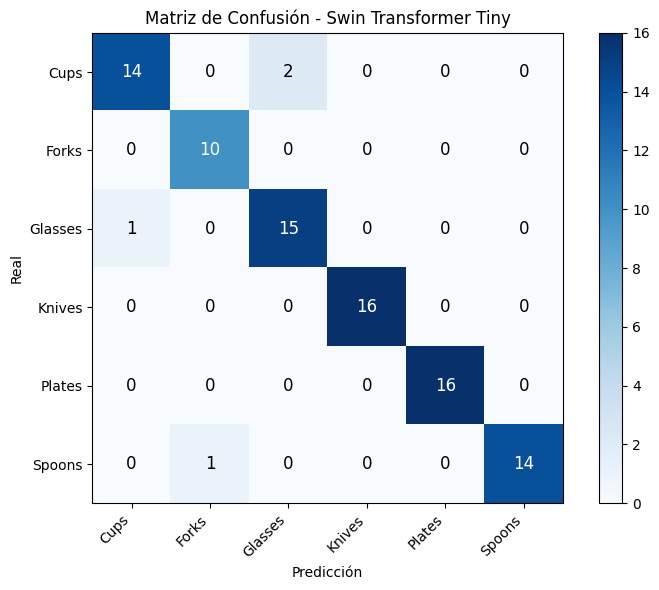

✓ Confusion matrix guardada como: swin_confusion_matrix.png


In [24]:
# CONFUSION MATRIX
cm = confusion_matrix(todas_etiquetas, todas_predicciones)
clases_nombres = train_set.classes

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im)

ax.set_xticks(range(len(clases_nombres)))
ax.set_yticks(range(len(clases_nombres)))
ax.set_xticklabels(clases_nombres, rotation=45, ha='right')
ax.set_yticklabels(clases_nombres)
ax.set_xlabel('Predicción')
ax.set_ylabel('Real')
ax.set_title('Matriz de Confusión - Swin Transformer Tiny')

# Números dentro de celdas
for i in range(len(clases_nombres)):
    for j in range(len(clases_nombres)):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', color=color, fontsize=12)

plt.tight_layout()
plt.savefig('swin_confusion_matrix.png', dpi=150)
plt.show()

print("✓ Confusion matrix guardada como: swin_confusion_matrix.png")

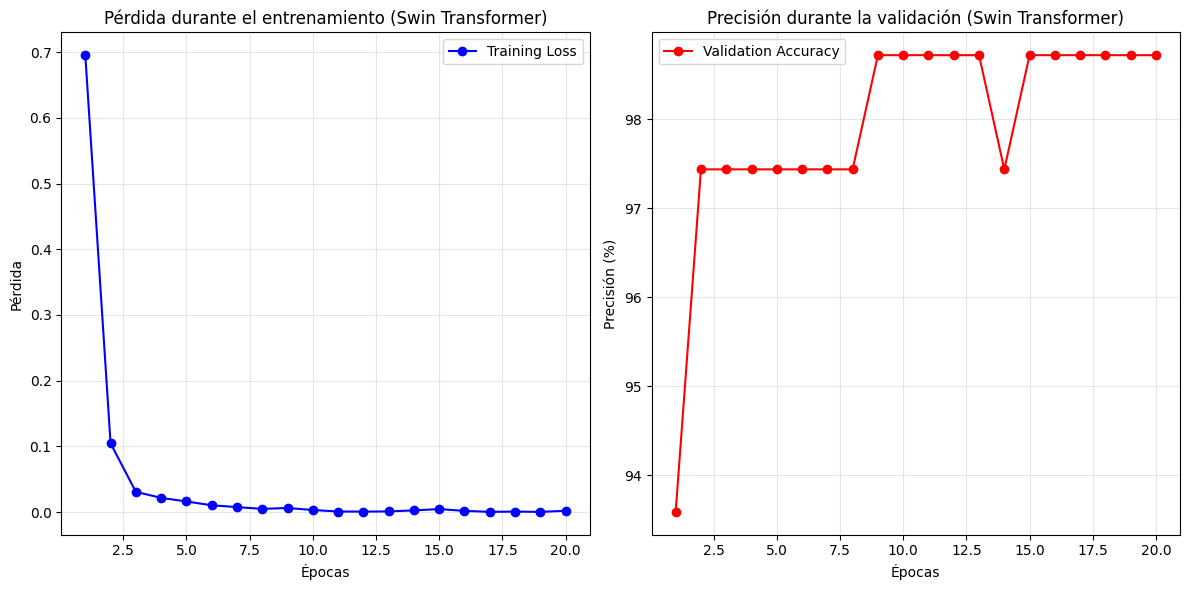

✓ Training curves guardadas como: swin_training_curves.png


In [25]:
# Learning curves
epochs_range = range(1, epochs + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Loss
ax1.plot(epochs_range, hist_loss_train, 'b-o', label='Training Loss')
ax1.set_title("Pérdida durante el entrenamiento (Swin Transformer)")
ax1.set_xlabel("Épocas")
ax1.set_ylabel("Pérdida")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(epochs_range, [a * 100 for a in hist_acc_val], 'r-o', label='Validation Accuracy')
ax2.set_title("Precisión durante la validación (Swin Transformer)")
ax2.set_xlabel("Épocas")
ax2.set_ylabel("Precisión (%)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('swin_training_curves.png', dpi=150)
plt.show()

print("✓ Training curves guardadas como: swin_training_curves.png")

Total de errores: 4 / 89
Tasa de error: 4.49%


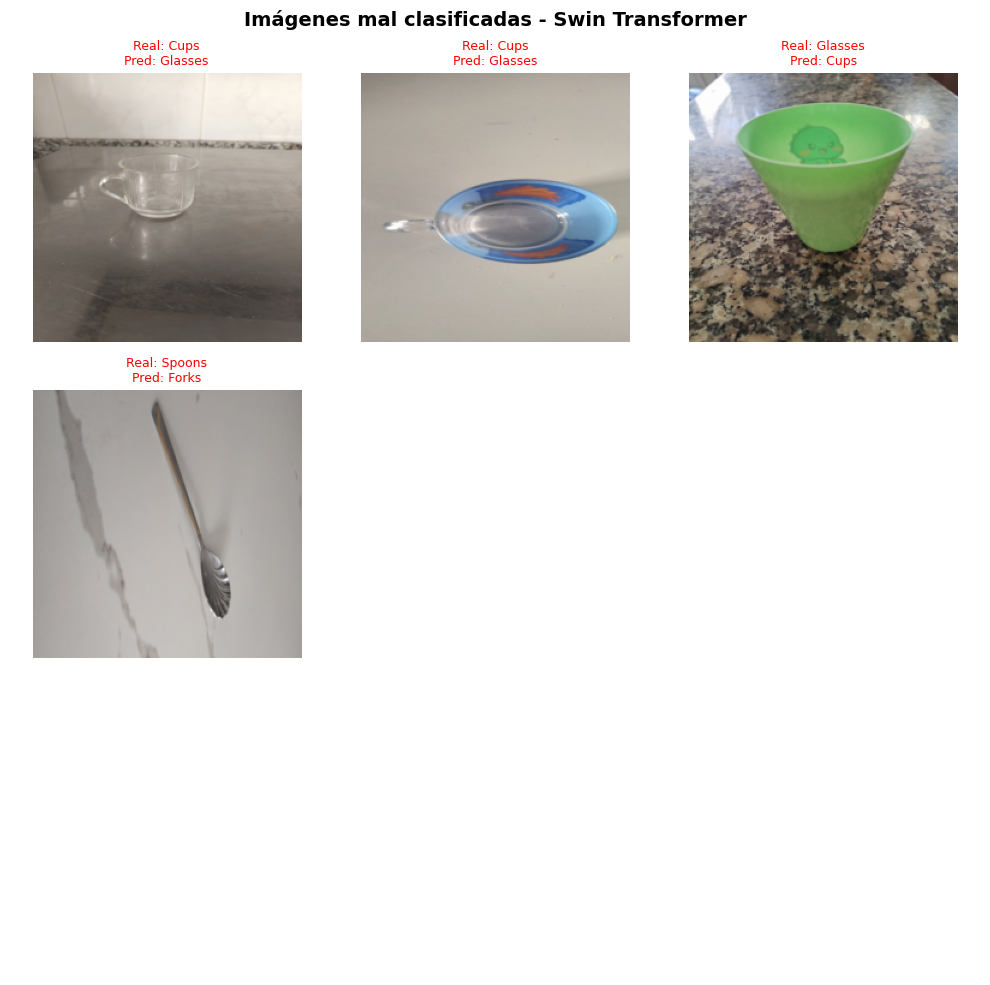

✓ Imágenes mal clasificadas guardadas como: swin_misclassified.png


In [26]:
# Encontrar imágenes mal clasificadas
errores_idx = [i for i in range(len(todas_predicciones))
               if todas_predicciones[i] != todas_etiquetas[i]]

print(f"Total de errores: {len(errores_idx)} / {len(todas_predicciones)}")
print(f"Tasa de error: {len(errores_idx)/len(todas_predicciones)*100:.2f}%")

# Mostrar hasta 9 imágenes mal clasificadas
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.flatten()

for idx, error_idx in enumerate(errores_idx[:9]):
    # Obtener imagen del test set
    img, label = test_set[error_idx]
    pred = todas_predicciones[error_idx]

    # Desnormalizar imagen para visualizar
    img_np = img.numpy().transpose(1, 2, 0)
    img_np = (img_np * np.array([0.229, 0.224, 0.225])) + np.array([0.485, 0.456, 0.406])
    img_np = np.clip(img_np, 0, 1)

    axes[idx].imshow(img_np)
    axes[idx].set_title(f"Real: {clases_nombres[label]}\nPred: {clases_nombres[pred]}",
                       color='red', fontsize=9)
    axes[idx].axis('off')

# Ocultar ejes sobrantes
for idx in range(len(errores_idx[:9]), 9):
    axes[idx].axis('off')

plt.suptitle('Imágenes mal clasificadas - Swin Transformer', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('swin_misclassified.png', dpi=150)
plt.show()

print("✓ Imágenes mal clasificadas guardadas como: swin_misclassified.png")

In [27]:
print("\n" + "="*80)
print("EXPERIMENTO 4: SWIN TRANSFORMER TINY - RESUMEN FINAL")
print("="*80)
print(f"\nModelo:                Swin Transformer Tiny")
print(f"Pre-entrenado:         ImageNet-1K")
print(f"Total parámetros:      {sum(p.numel() for p in modelo_swin.parameters()):,}")
print(f"Epochs:                {epochs}")
print(f"Batch size:            {batch_size}")
print(f"Optimizer:             AdamW (lr=0.00005)")
print(f"Loss function:         CrossEntropyLoss")
print(f"\nRESULTADOS EN TEST:")
print(f"  Accuracy:            {acc_test:.2f}%")
print(f"  Macro F1-Score:      {f1:.4f}")
print(f"  Errores:             {len(errores_idx)} / {len(todas_predicciones)}")
print(f"\nTIEMPO DE ENTRENAMIENTO:")
print(f"  {training_time:.1f} segundos ({training_time/60:.1f} minutos)")
print(f"  Device:              {device}")
print("="*80 + "\n")


EXPERIMENTO 4: SWIN TRANSFORMER TINY - RESUMEN FINAL

Modelo:                Swin Transformer Tiny
Pre-entrenado:         ImageNet-1K
Total parámetros:      27,523,968
Epochs:                20
Batch size:            16
Optimizer:             AdamW (lr=0.00005)
Loss function:         CrossEntropyLoss

RESULTADOS EN TEST:
  Accuracy:            95.51%
  Macro F1-Score:      0.9550
  Errores:             4 / 89

TIEMPO DE ENTRENAMIENTO:
  1110.8 segundos (18.5 minutos)
  Device:              cuda

